
# Financial Stress Early-Warning System

**Author:** Briana Love Whylie  
**Portfolio focus:** SQL, Python, quantitative research, statistics, and machine learning

## Research question

> Can information available today help identify whether the market is at elevated risk of a major decline during the next 20 trading days?

This notebook:

1. Downloads market data and Federal Reserve economic data.
2. Cleans and validates the datasets.
3. Creates a relational SQLite database.
4. Uses SQL CTEs and window functions to calculate market indicators.
5. Engineers quantitative risk features in Python.
6. Defines a future market-stress target without using future information as model inputs.
7. Trains and evaluates a time-ordered classification model.
8. Exports results that can be uploaded to GitHub.

> This project is for research and portfolio purposes, not investment advice.



## 1. Install the required packages



In [27]:
!pip -q install yfinance pandas-datareader scikit-learn

## 2. Import libraries and choose the research period

In [28]:

from datetime import date, timedelta
from pathlib import Path
import json
import sqlite3
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from pandas_datareader import data as web

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

START_DATE = "2005-01-01"
END_DATE = (date.today() + timedelta(days=1)).isoformat()

PROJECT_DIR = Path("/content/financial_stress_project")
DATA_DIR = PROJECT_DIR / "data"
SQL_DIR = PROJECT_DIR / "sql"
REPORT_DIR = PROJECT_DIR / "reports"
IMAGE_DIR = PROJECT_DIR / "images"

for folder in [PROJECT_DIR, DATA_DIR, SQL_DIR, REPORT_DIR, IMAGE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Research period: {START_DATE} through {END_DATE}")
print(f"Project files will be saved in: {PROJECT_DIR}")


Research period: 2005-01-01 through 2026-08-06
Project files will be saved in: /content/financial_stress_project



## 3. Download market data

The project uses SPY as the broad U.S. stock-market proxy, QQQ and IWM as additional risk indicators, and major sector ETFs to measure market breadth and dispersion.


In [29]:

TICKERS = {
    "SPY": "S&P 500 ETF",
    "QQQ": "Nasdaq-100 ETF",
    "IWM": "Russell 2000 ETF",
    "XLB": "Materials sector",
    "XLC": "Communication Services sector",
    "XLE": "Energy sector",
    "XLF": "Financials sector",
    "XLI": "Industrials sector",
    "XLK": "Technology sector",
    "XLP": "Consumer Staples sector",
    "XLRE": "Real Estate sector",
    "XLU": "Utilities sector",
    "XLV": "Health Care sector",
    "XLY": "Consumer Discretionary sector",
}

raw_market = yf.download(
    tickers=list(TICKERS),
    start=START_DATE,
    end=END_DATE,
    interval="1d",
    auto_adjust=False,
    group_by="ticker",
    progress=False,
    threads=True,
)

if raw_market.empty:
    raise RuntimeError("No market data downloaded. Rerun the cell or check the internet connection.")

market_frames = []

for ticker, asset_name in TICKERS.items():
    if isinstance(raw_market.columns, pd.MultiIndex):
        if ticker not in raw_market.columns.get_level_values(0):
            print(f"Warning: {ticker} was not returned and will be skipped.")
            continue
        ticker_data = raw_market[ticker].copy()
    else:
        ticker_data = raw_market.copy()

    ticker_data = ticker_data.reset_index()
    ticker_data.columns = [
        str(column).strip().lower().replace(" ", "_")
        for column in ticker_data.columns
    ]

    if "date" not in ticker_data.columns:
        ticker_data = ticker_data.rename(columns={ticker_data.columns[0]: "date"})

    ticker_data["ticker"] = ticker
    ticker_data["asset_name"] = asset_name

    if "adj_close" not in ticker_data.columns:
        ticker_data["adj_close"] = ticker_data["close"]

    ticker_data = ticker_data[
        [
            "date",
            "ticker",
            "asset_name",
            "open",
            "high",
            "low",
            "close",
            "adj_close",
            "volume",
        ]
    ]
    market_frames.append(ticker_data)

market_prices = pd.concat(market_frames, ignore_index=True)
market_prices["date"] = pd.to_datetime(market_prices["date"]).dt.tz_localize(None)
market_prices = market_prices.sort_values(["ticker", "date"]).reset_index(drop=True)

print(f"Market rows: {len(market_prices):,}")
print(f"Tickers downloaded: {market_prices['ticker'].nunique()}")
market_prices.head()


Market rows: 76,034
Tickers downloaded: 14


,date,ticker,asset_name,open,high,low,close,adj_close,volume
0,2005-01-03,IWM,Russell 2000 ETF,65.0950,65.2100,63.5700,63.9100,48.0750,"16,062,600.0000"
1,2005-01-04,IWM,Russell 2000 ETF,64.0350,64.0850,62.4300,62.5400,47.0444,"27,450,000.0000"
2,2005-01-05,IWM,Russell 2000 ETF,62.4700,62.6400,61.2900,61.2900,46.1042,"29,884,200.0000"
3,2005-01-06,IWM,Russell 2000 ETF,61.6700,62.2000,61.2250,61.6150,46.3486,"23,061,200.0000"
4,2005-01-07,IWM,Russell 2000 ETF,61.7550,61.9500,60.8950,60.9300,45.8333,"20,906,200.0000"



## 4. Download Federal Reserve economic indicators

Monthly indicators will later be delayed before entering the model to approximate the fact that economic reports are published after their observation period.


In [30]:

FRED_SERIES = {
    "VIXCLS": "vix",
    "DGS10": "treasury_10y",
    "DGS2": "treasury_2y",
    "FEDFUNDS": "federal_funds_rate",
    "UNRATE": "unemployment_rate",
    "CPIAUCSL": "consumer_price_index",
}

fred_data = web.DataReader(
    list(FRED_SERIES),
    "fred",
    START_DATE,
    END_DATE,
).rename(columns=FRED_SERIES)

fred_data.index = pd.to_datetime(fred_data.index)
fred_data.index.name = "date"
fred_data = fred_data.apply(pd.to_numeric, errors="coerce").sort_index()

if fred_data.empty:
    raise RuntimeError("No FRED data downloaded. Rerun the cell or check the internet connection.")

print(f"FRED rows: {len(fred_data):,}")
fred_data.tail()


FRED rows: 5,706


,vix,treasury_10y,treasury_2y,federal_funds_rate,unemployment_rate,consumer_price_index
date,,,,,,
2026-07-29,20.6600,4.6700,4.2200,NaN,NaN,NaN
2026-07-30,17.0900,4.6800,4.2300,NaN,NaN,NaN
2026-07-31,15.9900,4.7500,4.2800,NaN,NaN,NaN
2026-08-03,15.8600,4.7000,4.2500,NaN,NaN,NaN
2026-08-04,16.5000,NaN,NaN,NaN,NaN,NaN


## 5. Run data-quality checks

In [31]:

quality_report = pd.DataFrame({
    "check": [
        "Duplicate market ticker-date rows",
        "Market rows with missing adjusted close",
        "Market rows with negative volume",
        "Market rows where high is below low",
        "Duplicate FRED dates",
        "FRED columns with at least one non-null value",
    ],
    "result": [
        int(market_prices.duplicated(["ticker", "date"]).sum()),
        int(market_prices["adj_close"].isna().sum()),
        int((market_prices["volume"].fillna(0) < 0).sum()),
        int((market_prices["high"] < market_prices["low"]).fillna(False).sum()),
        int(fred_data.index.duplicated().sum()),
        int(fred_data.notna().any().sum()),
    ],
})

quality_report


,check,result
0,Duplicate market ticker-date rows,0
1,Market rows with missing adjusted close,6098
2,Market rows with negative volume,0
3,Market rows where high is below low,0
4,Duplicate FRED dates,0
5,FRED columns with at least one non-null value,6


In [32]:

critical_failures = {
    "duplicate market keys": market_prices.duplicated(["ticker", "date"]).any(),
    "negative market volume": (market_prices["volume"].fillna(0) < 0).any(),
    "invalid daily high/low": (market_prices["high"] < market_prices["low"]).fillna(False).any(),
}

failed_checks = [name for name, failed in critical_failures.items() if failed]

if failed_checks:
    raise ValueError(f"Critical data-quality checks failed: {failed_checks}")

market_prices = market_prices.dropna(subset=["date", "ticker", "adj_close"]).copy()
market_prices["volume"] = market_prices["volume"].fillna(0).astype("int64")

print("Critical data-quality checks passed.")


Critical data-quality checks passed.



## 6. Create a SQL database

SQLite runs directly inside Colab, allowing this notebook to demonstrate relational tables, indexes, views, CTEs, `LAG()`, and rolling window calculations without requiring a separate database server.


In [33]:

DATABASE_PATH = PROJECT_DIR / "financial_stress.db"

if DATABASE_PATH.exists():
    DATABASE_PATH.unlink()

connection = sqlite3.connect(DATABASE_PATH)

market_sql = market_prices.rename(
    columns={"date": "price_date", "adj_close": "adjusted_close"}
).copy()
market_sql["price_date"] = market_sql["price_date"].dt.strftime("%Y-%m-%d")

fred_long = (
    fred_data.reset_index()
    .melt(id_vars="date", var_name="indicator_name", value_name="indicator_value")
    .dropna(subset=["indicator_value"])
)
fred_long["date"] = fred_long["date"].dt.strftime("%Y-%m-%d")

market_sql.to_sql("market_prices", connection, index=False, if_exists="replace")
fred_long.to_sql("economic_indicators", connection, index=False, if_exists="replace")

connection.executescript(
    '''
    CREATE UNIQUE INDEX idx_market_ticker_date
        ON market_prices (ticker, price_date);

    CREATE INDEX idx_market_date
        ON market_prices (price_date);

    CREATE INDEX idx_economic_indicator_date
        ON economic_indicators (indicator_name, date);
    '''
)

table_counts = pd.read_sql_query(
    '''
    SELECT 'market_prices' AS table_name, COUNT(*) AS row_count
    FROM market_prices
    UNION ALL
    SELECT 'economic_indicators', COUNT(*)
    FROM economic_indicators;
    ''',
    connection,
)

table_counts


,table_name,row_count
0,market_prices,69936
1,economic_indicators,17035


## 7. Use SQL window functions to build market features

In [34]:

MARKET_FEATURES_SQL = '''
DROP VIEW IF EXISTS market_features_sql;

CREATE VIEW market_features_sql AS
WITH base AS (
    SELECT
        price_date,
        ticker,
        asset_name,
        adjusted_close,
        volume,
        LAG(adjusted_close, 1) OVER (
            PARTITION BY ticker
            ORDER BY price_date
        ) AS previous_close,
        AVG(adjusted_close) OVER (
            PARTITION BY ticker
            ORDER BY price_date
            ROWS BETWEEN 19 PRECEDING AND CURRENT ROW
        ) AS moving_average_20d,
        AVG(volume) OVER (
            PARTITION BY ticker
            ORDER BY price_date
            ROWS BETWEEN 19 PRECEDING AND CURRENT ROW
        ) AS average_volume_20d,
        MAX(adjusted_close) OVER (
            PARTITION BY ticker
            ORDER BY price_date
            ROWS BETWEEN 251 PRECEDING AND CURRENT ROW
        ) AS rolling_peak_252d
    FROM market_prices
),
calculated AS (
    SELECT
        price_date,
        ticker,
        asset_name,
        adjusted_close,
        volume,
        CASE
            WHEN previous_close IS NULL OR previous_close = 0 THEN NULL
            ELSE adjusted_close / previous_close - 1.0
        END AS daily_return,
        CASE
            WHEN moving_average_20d IS NULL OR moving_average_20d = 0 THEN NULL
            ELSE adjusted_close / moving_average_20d - 1.0
        END AS price_vs_ma20,
        CASE
            WHEN average_volume_20d IS NULL OR average_volume_20d = 0 THEN NULL
            ELSE volume / average_volume_20d - 1.0
        END AS volume_vs_average_20d,
        CASE
            WHEN rolling_peak_252d IS NULL OR rolling_peak_252d = 0 THEN NULL
            ELSE adjusted_close / rolling_peak_252d - 1.0
        END AS drawdown_252d
    FROM base
)
SELECT *
FROM calculated;
'''

connection.executescript(MARKET_FEATURES_SQL)
SQL_DIR.joinpath("03_market_indicators.sql").write_text(
    MARKET_FEATURES_SQL,
    encoding="utf-8",
)

market_features_sql = pd.read_sql_query(
    '''
    SELECT *
    FROM market_features_sql
    ORDER BY ticker, price_date;
    ''',
    connection,
    parse_dates=["price_date"],
)

market_features_sql.head()


,price_date,ticker,asset_name,adjusted_close,volume,daily_return,price_vs_ma20,volume_vs_average_20d,drawdown_252d
0,2005-01-03,IWM,Russell 2000 ETF,48.0750,16062600,NaN,0.0000,0.0000,0.0000
1,2005-01-04,IWM,Russell 2000 ETF,47.0444,27450000,-0.0214,-0.0108,0.2617,-0.0214
2,2005-01-05,IWM,Russell 2000 ETF,46.1042,29884200,-0.0200,-0.0206,0.2215,-0.0410
3,2005-01-06,IWM,Russell 2000 ETF,46.3486,23061200,0.0053,-0.0116,-0.0437,-0.0359
4,2005-01-07,IWM,Russell 2000 ETF,45.8333,20906200,-0.0111,-0.0182,-0.1093,-0.0466


## 8. Create quantitative market features in Python

In [35]:

spy = (
    market_features_sql.loc[market_features_sql["ticker"] == "SPY"]
    .sort_values("price_date")
    .set_index("price_date")
    .copy()
)

spy["rolling_volatility_20d"] = spy["daily_return"].rolling(20).std() * np.sqrt(252)
spy["momentum_20d"] = spy["adjusted_close"].pct_change(20)
spy["momentum_60d"] = spy["adjusted_close"].pct_change(60)
spy["return_5d"] = spy["adjusted_close"].pct_change(5)
spy["volume_zscore_20d"] = (
    (spy["volume"] - spy["volume"].rolling(20).mean())
    / spy["volume"].rolling(20).std()
)

price_wide = market_prices.pivot(
    index="date",
    columns="ticker",
    values="adj_close",
).sort_index()

sector_tickers = [ticker for ticker in TICKERS if ticker.startswith("XL")]
sector_returns_20d = price_wide[sector_tickers].pct_change(20)

sector_breadth_20d = (
    sector_returns_20d.gt(0).sum(axis=1)
    / sector_returns_20d.notna().sum(axis=1)
).rename("sector_breadth_20d")

sector_dispersion_20d = sector_returns_20d.std(axis=1).rename(
    "sector_dispersion_20d"
)

small_cap_relative_return_20d = (
    price_wide["IWM"].pct_change(20)
    - price_wide["SPY"].pct_change(20)
).rename("small_cap_relative_return_20d")

spy = spy.join(
    [
        sector_breadth_20d,
        sector_dispersion_20d,
        small_cap_relative_return_20d,
    ]
)

spy.tail()


,ticker,asset_name,adjusted_close,volume,daily_return,price_vs_ma20,volume_vs_average_20d,drawdown_252d,rolling_volatility_20d,momentum_20d,momentum_60d,return_5d,volume_zscore_20d,sector_breadth_20d,sector_dispersion_20d,small_cap_relative_return_20d
price_date,,,,,,,,,,,,,,,,
2026-07-30,SPY,S&P 500 ETF,741.6900,66811300,0.0168,-0.0052,0.3986,-0.0210,0.1243,-0.0055,0.0356,0.0048,1.8446,0.5455,0.0483,-0.0170
2026-07-31,SPY,S&P 500 ETF,747.0300,62445900,0.0072,0.0018,0.3004,-0.0140,0.1269,0.0030,0.0348,0.0110,1.3577,0.3636,0.0427,-0.0245
2026-08-03,SPY,S&P 500 ETF,757.6700,59927500,0.0142,0.0156,0.2361,0.0000,0.1332,0.0085,0.0351,0.0251,1.0458,0.6364,0.0368,-0.0175
2026-08-04,SPY,S&P 500 ETF,771.3300,69059900,0.0180,0.0323,0.3882,0.0000,0.1454,0.0316,0.0571,0.0411,1.6369,0.8182,0.0281,-0.0130
2026-08-05,SPY,S&P 500 ETF,771.8450,32244393,0.0007,0.0312,-0.3443,0.0000,0.1444,0.0355,0.0491,0.0581,-1.3683,0.9091,0.0259,-0.0109



## 9. Align economic indicators without obvious look-ahead leakage

The notebook applies approximate publication delays to monthly indicators. A more advanced future version could use exact release calendars or real-time vintage data.


In [36]:

calendar_index = pd.date_range(
    start=spy.index.min(),
    end=spy.index.max(),
    freq="D",
)

macro_daily = fred_data.reindex(calendar_index).ffill()

macro_features = pd.DataFrame(index=calendar_index)
macro_features["vix"] = macro_daily["vix"]
macro_features["treasury_10y"] = macro_daily["treasury_10y"]
macro_features["treasury_2y"] = macro_daily["treasury_2y"]
macro_features["yield_curve_10y_2y"] = (
    macro_daily["treasury_10y"] - macro_daily["treasury_2y"]
)

macro_features["unemployment_rate_lagged"] = (
    macro_daily["unemployment_rate"].shift(35)
)
macro_features["federal_funds_rate_lagged"] = (
    macro_daily["federal_funds_rate"].shift(35)
)

inflation_yoy = macro_daily["consumer_price_index"].pct_change(365) * 100
macro_features["inflation_yoy_lagged"] = inflation_yoy.shift(45)

spy = spy.join(macro_features, how="left").ffill()

spy[
    [
        "vix",
        "yield_curve_10y_2y",
        "unemployment_rate_lagged",
        "inflation_yoy_lagged",
    ]
].tail()


,vix,yield_curve_10y_2y,unemployment_rate_lagged,inflation_yoy_lagged
price_date,,,,
2026-07-30,17.0900,0.4500,4.2000,3.4635
2026-07-31,15.9900,0.4700,4.2000,3.4635
2026-08-03,15.8600,0.4500,4.2000,3.4635
2026-08-04,16.5000,0.4500,4.2000,3.4635
2026-08-05,16.5000,0.4500,4.2000,3.4635



## 10. Define the future stress target

A date receives a label of `1` when SPY falls at least 8% from that day's closing price at any point during the following 20 trading days.

Future prices create only the target. They are not model inputs.


In [37]:

close_values = spy["adjusted_close"].to_numpy()
future_minimum_20d = np.full(len(spy), np.nan)

for row_number in range(len(spy) - 20):
    future_window = close_values[row_number + 1 : row_number + 21]
    future_minimum_20d[row_number] = np.min(future_window)

spy["future_minimum_close_20d"] = future_minimum_20d
spy["future_drawdown_20d"] = (
    spy["future_minimum_close_20d"] / spy["adjusted_close"] - 1
)
spy["stress_next_20d"] = (
    spy["future_drawdown_20d"] <= -0.08
).astype("Int64")

target_summary = (
    spy["stress_next_20d"]
    .value_counts(dropna=False)
    .rename_axis("stress_label")
    .to_frame("rows")
)
target_summary["percentage"] = (
    target_summary["rows"] / target_summary["rows"].sum() * 100
)

target_summary


,rows,percentage
stress_label,,
0,5063,93.2241
1,368,6.7759


## 11. Visualize the market and labeled stress periods

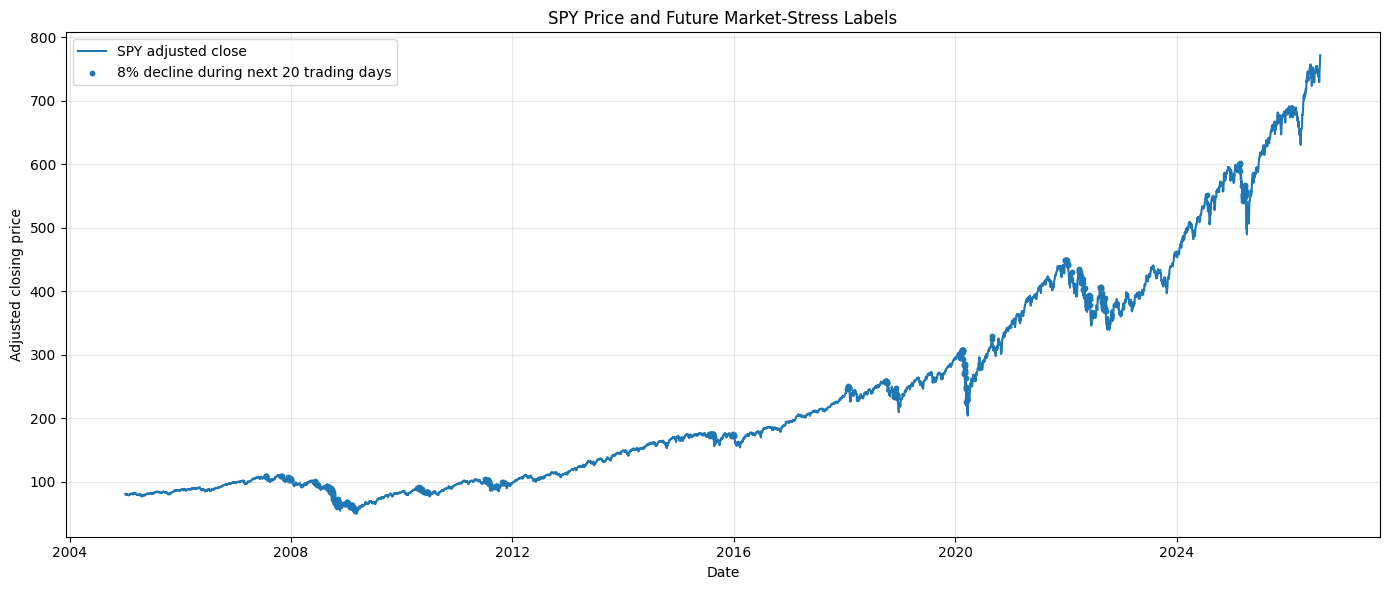

In [38]:

plot_data = spy.dropna(subset=["stress_next_20d"]).copy()

plt.figure(figsize=(14, 6))
plt.plot(plot_data.index, plot_data["adjusted_close"], label="SPY adjusted close")

stress_dates = plot_data.index[plot_data["stress_next_20d"] == 1]
plt.scatter(
    stress_dates,
    plot_data.loc[stress_dates, "adjusted_close"],
    s=10,
    label="8% decline during next 20 trading days",
)

plt.title("SPY Price and Future Market-Stress Labels")
plt.xlabel("Date")
plt.ylabel("Adjusted closing price")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "spy_stress_labels.png", dpi=200, bbox_inches="tight")
plt.show()


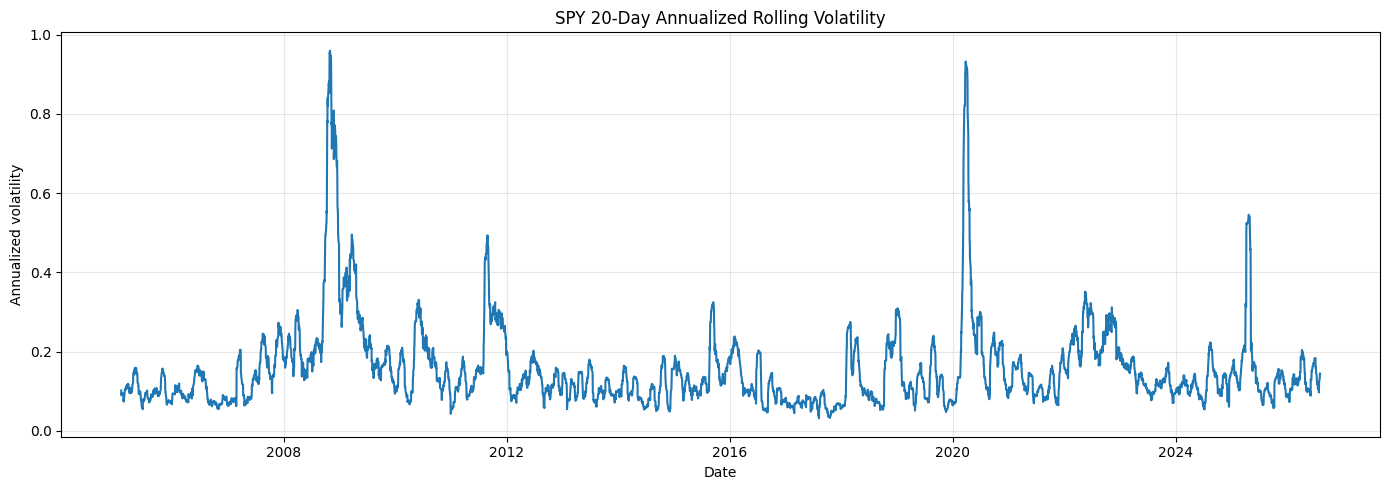

In [39]:

plt.figure(figsize=(14, 5))
plt.plot(spy.index, spy["rolling_volatility_20d"])
plt.title("SPY 20-Day Annualized Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized volatility")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "rolling_volatility.png", dpi=200, bbox_inches="tight")
plt.show()


## 12. Build the modeling dataset

In [40]:

FEATURE_COLUMNS = [
    "rolling_volatility_20d",
    "momentum_20d",
    "momentum_60d",
    "return_5d",
    "price_vs_ma20",
    "volume_vs_average_20d",
    "volume_zscore_20d",
    "drawdown_252d",
    "sector_breadth_20d",
    "sector_dispersion_20d",
    "small_cap_relative_return_20d",
    "vix",
    "treasury_10y",
    "treasury_2y",
    "yield_curve_10y_2y",
    "unemployment_rate_lagged",
    "federal_funds_rate_lagged",
    "inflation_yoy_lagged",
]

model_data = (
    spy[FEATURE_COLUMNS + ["stress_next_20d", "future_drawdown_20d"]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["stress_next_20d"])
    .copy()
)

model_data["stress_next_20d"] = model_data["stress_next_20d"].astype(int)
model_data = model_data.loc[model_data.index >= pd.Timestamp("2007-01-01")]

print(f"Model rows: {len(model_data):,}")
print(f"Stress-label rate: {model_data['stress_next_20d'].mean():.2%}")
model_data.head()


Model rows: 4,928
Stress-label rate: 7.47%


,rolling_volatility_20d,momentum_20d,momentum_60d,return_5d,price_vs_ma20,volume_vs_average_20d,volume_zscore_20d,drawdown_252d,sector_breadth_20d,sector_dispersion_20d,small_cap_relative_return_20d,vix,treasury_10y,treasury_2y,yield_curve_10y_2y,unemployment_rate_lagged,federal_funds_rate_lagged,inflation_yoy_lagged,stress_next_20d,future_drawdown_20d
price_date,,,,,,,,,,,,,,,,,,,,
2007-01-03,0.0675,0.0138,0.0516,0.0044,-0.0007,0.6049,2.0166,-0.0080,0.8889,0.0320,-0.0047,12.0400,4.6700,4.7600,-0.0900,4.5000,5.2500,1.9687,0,-0.0059
2007-01-04,0.0626,0.0083,0.0552,0.0006,0.0010,0.1970,0.6902,-0.0059,0.6667,0.0340,-0.0161,11.5100,4.6200,4.7100,-0.0900,4.5000,5.2500,1.9687,0,-0.0080
2007-01-05,0.0675,-0.0041,0.0461,-0.0138,-0.0068,0.3140,1.0922,-0.0138,0.5556,0.0298,-0.0252,12.1400,4.6500,4.7600,-0.1100,4.4000,5.2400,1.9687,0,0.0038
2007-01-08,0.0696,0.0014,0.0496,-0.0072,-0.0022,0.2094,0.7306,-0.0093,0.6667,0.0296,-0.0312,12.0000,4.6600,4.7800,-0.1200,4.4000,5.2400,1.9687,0,-0.0008
2007-01-09,0.0677,0.0049,0.0499,-0.0039,-0.0033,0.2637,0.9094,-0.0101,0.6667,0.0320,-0.0213,11.9100,4.6600,4.7900,-0.1300,4.4000,5.2400,1.9687,0,0.0033



## 13. Split the data by time

The first 80% of dates are used for training. The final 20% are held out for testing. This avoids randomly mixing later observations into the training period.


In [41]:

split_position = int(len(model_data) * 0.80)

train_data = model_data.iloc[:split_position].copy()
test_data = model_data.iloc[split_position:].copy()

X_train = train_data[FEATURE_COLUMNS]
y_train = train_data["stress_next_20d"]
X_test = test_data[FEATURE_COLUMNS]
y_test = test_data["stress_next_20d"]

print(f"Training period: {train_data.index.min().date()} to {train_data.index.max().date()}")
print(f"Testing period:  {test_data.index.min().date()} to {test_data.index.max().date()}")
print(f"Training rows: {len(train_data):,}")
print(f"Testing rows:  {len(test_data):,}")
print(f"Training stress rate: {y_train.mean():.2%}")
print(f"Testing stress rate:  {y_test.mean():.2%}")


Training period: 2007-01-03 to 2022-08-29
Testing period:  2022-08-30 to 2026-08-05
Training rows: 3,942
Testing rows:  986
Training stress rate: 8.30%
Testing stress rate:  4.16%



## 14. Train a transparent baseline model

Logistic regression is interpretable and provides a strong baseline. Class weighting helps account for the lower frequency of severe stress periods.


In [42]:

model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=3000,
                random_state=42,
            ),
        ),
    ]
)

model.fit(X_train, y_train)

test_probabilities = model.predict_proba(X_test)[:, 1]
test_predictions_default = (test_probabilities >= 0.50).astype(int)

print(
    classification_report(
        y_test,
        test_predictions_default,
        digits=3,
        zero_division=0,
    )
)

if y_test.nunique() == 2:
    test_roc_auc = roc_auc_score(y_test, test_probabilities)
    print(f"Test ROC-AUC: {test_roc_auc:.3f}")
else:
    test_roc_auc = np.nan
    print("ROC-AUC could not be calculated because the test period contains one class.")


              precision    recall  f1-score   support

           0      0.976     0.392     0.559       945
           1      0.053     0.780     0.099        41

    accuracy                          0.408       986
   macro avg      0.514     0.586     0.329       986
weighted avg      0.938     0.408     0.540       986

Test ROC-AUC: 0.625



## 15. Select an early-warning threshold

The threshold is selected only from the training period. It targets approximately 70% recall, then remains fixed when evaluated on the test period.


In [43]:

train_probabilities = model.predict_proba(X_train)[:, 1]

precision, recall, thresholds = precision_recall_curve(
    y_train,
    train_probabilities,
)

target_recall = 0.70
eligible_positions = np.where(recall[:-1] >= target_recall)[0]

if len(eligible_positions) > 0:
    best_position = eligible_positions[
        np.argmax(precision[:-1][eligible_positions])
    ]
    selected_threshold = float(thresholds[best_position])
else:
    selected_threshold = 0.50

test_predictions = (test_probabilities >= selected_threshold).astype(int)

print(f"Selected probability threshold: {selected_threshold:.3f}")
print(
    classification_report(
        y_test,
        test_predictions,
        digits=3,
        zero_division=0,
    )
)


Selected probability threshold: 0.509
              precision    recall  f1-score   support

           0      0.977     0.412     0.579       945
           1      0.054     0.780     0.102        41

    accuracy                          0.427       986
   macro avg      0.516     0.596     0.341       986
weighted avg      0.939     0.427     0.559       986



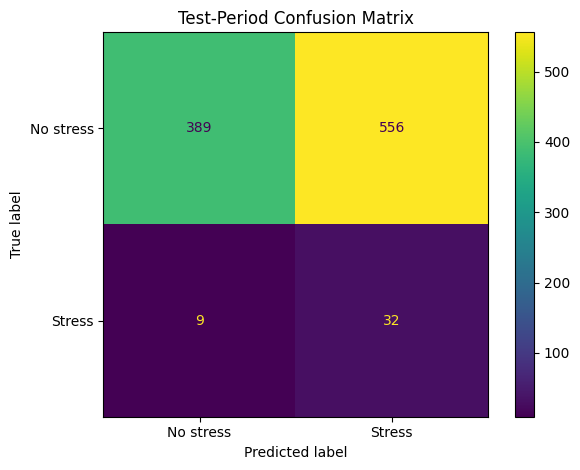

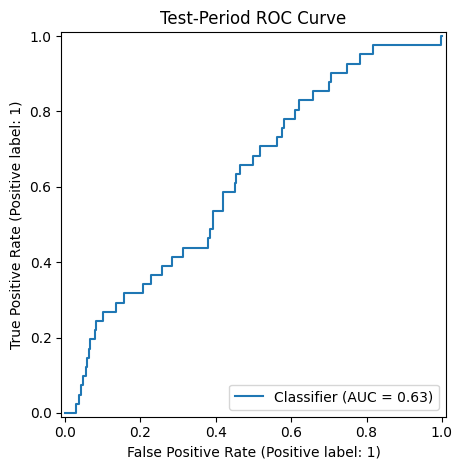

In [44]:

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    display_labels=["No stress", "Stress"],
)
plt.title("Test-Period Confusion Matrix")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

if y_test.nunique() == 2:
    RocCurveDisplay.from_predictions(y_test, test_probabilities)
    plt.title("Test-Period ROC Curve")
    plt.tight_layout()
    plt.savefig(IMAGE_DIR / "roc_curve.png", dpi=200, bbox_inches="tight")
    plt.show()


## 16. Interpret the model

In [45]:

coefficients = (
    pd.DataFrame(
        {
            "feature": FEATURE_COLUMNS,
            "coefficient": model.named_steps["classifier"].coef_[0],
        }
    )
    .assign(
        absolute_coefficient=lambda frame: frame["coefficient"].abs(),
        relationship=lambda frame: np.where(
            frame["coefficient"] > 0,
            "Higher value associated with greater modeled stress risk",
            "Higher value associated with lower modeled stress risk",
        ),
    )
    .sort_values("absolute_coefficient", ascending=False)
    .reset_index(drop=True)
)

coefficients.head(12)


,feature,coefficient,absolute_coefficient,relationship
0,momentum_20d,0.7972,0.7972,Higher value associated with greater modeled s...
1,federal_funds_rate_lagged,-0.7512,0.7512,Higher value associated with lower modeled str...
2,rolling_volatility_20d,0.7116,0.7116,Higher value associated with greater modeled s...
3,price_vs_ma20,-0.6642,0.6642,Higher value associated with lower modeled str...
4,treasury_10y,0.6517,0.6517,Higher value associated with greater modeled s...
5,treasury_2y,0.4637,0.4637,Higher value associated with greater modeled s...
6,inflation_yoy_lagged,0.4355,0.4355,Higher value associated with greater modeled s...
7,sector_dispersion_20d,0.3982,0.3982,Higher value associated with greater modeled s...
8,unemployment_rate_lagged,-0.3961,0.3961,Higher value associated with lower modeled str...
9,small_cap_relative_return_20d,-0.3304,0.3304,Higher value associated with lower modeled str...


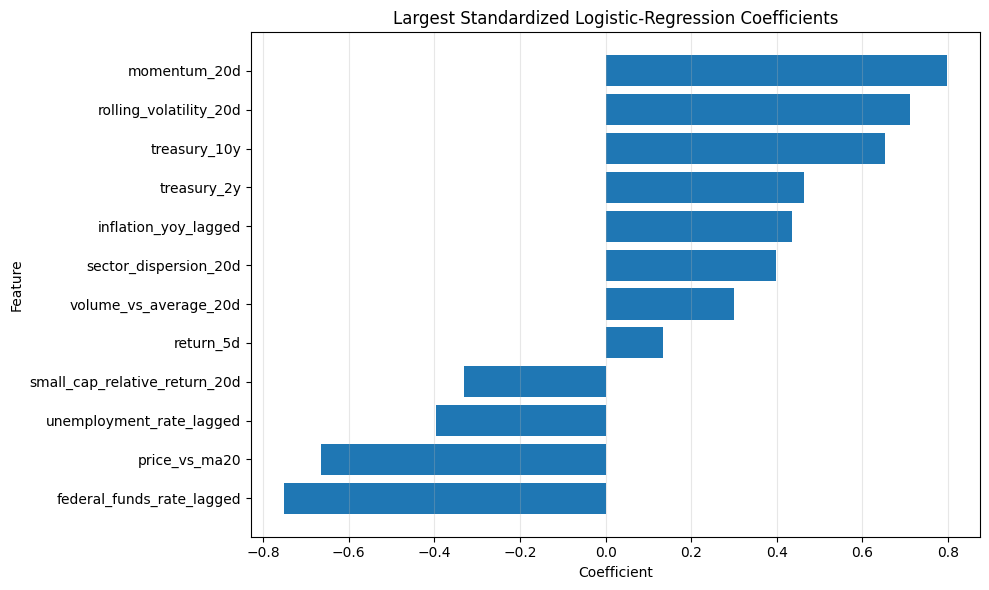

In [46]:

top_coefficients = coefficients.head(12).sort_values("coefficient")

plt.figure(figsize=(10, 6))
plt.barh(
    top_coefficients["feature"],
    top_coefficients["coefficient"],
)
plt.title("Largest Standardized Logistic-Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "feature_coefficients.png", dpi=200, bbox_inches="tight")
plt.show()


## 17. Review the highest-risk test dates

In [47]:

test_results = test_data[["stress_next_20d", "future_drawdown_20d"]].copy()
test_results["predicted_stress_probability"] = test_probabilities
test_results["predicted_label"] = test_predictions

highest_risk_dates = (
    test_results
    .sort_values("predicted_stress_probability", ascending=False)
    .head(20)
)

highest_risk_dates


,stress_next_20d,future_drawdown_20d,predicted_stress_probability,predicted_label
price_date,,,,
2022-10-24,0,-0.0207,0.9902,1
2022-10-21,0,-0.0088,0.9895,1
2022-11-09,0,0.0509,0.9862,1
2022-10-28,0,-0.0463,0.9845,1
2022-10-25,0,-0.0361,0.9836,1
2022-11-08,0,-0.0206,0.9813,1
2022-11-11,0,-0.0134,0.9806,1
2022-12-05,0,-0.0531,0.9789,1
2022-10-27,0,-0.0236,0.9777,1


## 18. Export GitHub-ready files

In [48]:

market_prices.to_csv(DATA_DIR / "market_prices_clean.csv", index=False)
fred_data.to_csv(DATA_DIR / "fred_indicators_clean.csv")
model_data.to_csv(DATA_DIR / "model_dataset.csv")
test_results.to_csv(REPORT_DIR / "test_predictions.csv")
coefficients.to_csv(REPORT_DIR / "feature_coefficients.csv", index=False)
quality_report.to_csv(REPORT_DIR / "data_quality_report.csv", index=False)

metrics = {
    "research_start": str(model_data.index.min().date()),
    "research_end": str(model_data.index.max().date()),
    "training_end": str(train_data.index.max().date()),
    "test_start": str(test_data.index.min().date()),
    "selected_probability_threshold": selected_threshold,
    "test_roc_auc": None if np.isnan(test_roc_auc) else float(test_roc_auc),
    "training_rows": int(len(train_data)),
    "testing_rows": int(len(test_data)),
    "training_stress_rate": float(y_train.mean()),
    "testing_stress_rate": float(y_test.mean()),
}

with open(REPORT_DIR / "model_metrics.json", "w", encoding="utf-8") as file:
    json.dump(metrics, file, indent=2)

report_text = f"""# Financial Stress Early-Warning System: Initial Results

## Research Question

Can information available today help identify whether the U.S. stock market is at elevated risk of a decline of at least 8% during the next 20 trading days?

## Research Design

- Market proxy: SPY
- Research period: {model_data.index.min().date()} through {model_data.index.max().date()}
- Training period ending: {train_data.index.max().date()}
- Test period beginning: {test_data.index.min().date()}
- Model: Class-weighted logistic regression
- Warning threshold: {selected_threshold:.3f}
- Test ROC-AUC: {"Not available" if np.isnan(test_roc_auc) else f"{test_roc_auc:.3f}"}

## Important Methodology Choices

- The train/test split follows chronological order.
- Future prices are used only to create the target.
- Monthly economic features are delayed to approximate publication lag.
- Features are imputed and standardized using parameters learned from the training period.

## Next Research Steps

1. Add exact economic release dates or real-time data vintages.
2. Compare logistic regression with tree-based models.
3. Use walk-forward validation across multiple market regimes.
4. Test alternative decline thresholds and forecast horizons.
5. Add transaction-cost-aware investment or hedging simulations.

## Disclaimer

This project is for educational and portfolio purposes and is not investment advice.
"""

(REPORT_DIR / "final_research_report.md").write_text(
    report_text,
    encoding="utf-8",
)

print("Exported files:")
for path in sorted(PROJECT_DIR.rglob("*")):
    if path.is_file():
        print(path.relative_to(PROJECT_DIR))


Exported files:
data/fred_indicators_clean.csv
data/market_prices_clean.csv
data/model_dataset.csv
financial_stress.db
images/confusion_matrix.png
images/feature_coefficients.png
images/roc_curve.png
images/rolling_volatility.png
images/spy_stress_labels.png
reports/data_quality_report.csv
reports/feature_coefficients.csv
reports/final_research_report.md
reports/model_metrics.json
reports/test_predictions.csv
sql/03_market_indicators.sql
